# Mean reversion (Pairs trading)

When two assets are said to be cointegrated, a linear combination of the time series of these two assets produces a stationary time series. This means that these assets will fluctuate around a long-run equilibrium, and their spread (the linear combination of their prices) will have a constant mean and variance. When this spread deviates significantly from its mean, we can construct a strategy that bets on reversion back to the mean, potentially generating profits. In this project, I use the Engle-Granger cointegration test to identify cointegrated pairs of stocks from a basket of arbitrarily selected companies in different sectors, and then trade deviations of the spread using z-score thresholds.

In [ ]:
# Will be using 'Close' data over a two year period for training and for testing

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import pandas_datareader as pdr
from datetime import datetime
import yfinance as yf

def get_histData(tickers, start, end):
    data = pd.DataFrame()
    names = list()
    for i in tickers:
        df = pd.DataFrame(yf.download(i, start=start, end=end, progress=False))
        data = pd.concat([data, df['Close']], axis=1)
        names.append(i)
    data.columns = names
    return data

TICKERS = [
    "AAPL","GOOG","SPY","NFLX","SNAP",   # tech + social
    "MSFT","AMZN","META","TSLA","NVDA",  # big tech
    "JPM","GS",                          # banks
    "XOM","CVX",                         # oil majors
    "WMT","NKE","BA"                     # consumer + industrial
]

TRAIN_START = datetime(2021, 8, 13)
TRAIN_END   = datetime(2023, 8, 13)

TEST_START  = datetime(2023, 8, 13)
TEST_END    = datetime(2025, 8, 13)

d_train = get_histData(TICKERS, TRAIN_START, TRAIN_END)
d_test  = get_histData(TICKERS, TEST_START, TEST_END)

# Gives rolling z-score time to warm up before test period
d_full = pd.concat([d_train, d_test[~d_test.index.isin(d_train.index)]]).sort_index()

print("train shape:", d_train.shape, "| test shape:", d_test.shape, "| full shape:", d_full.shape)
d_train.tail()

I apply the Engle-Granger two step test, where you take two non stationary time series and determine whether both series become stationary after the same order of differencing. I regress one log price series on the other, then test whether the residuals are stationary (i.e., do not contain a unit root). If the residuals are stationary, the pair is considered cointegrated. While unit roots in non-stationary price series can often be handled by differencing, here the focus is specifically identifying stationary spreads suitable for trading.

In [7]:
import numpy as np
import itertools
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

PCOFF = 0.05

def ols_beta(y: pd.Series, x: pd.Series):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    a, b = model.params
    resid = y - (a + b * x)
    return a, b, resid

def find_cointegrated_pairs(prices: pd.DataFrame, pval_cutoff=0.05):
    logp = np.log(prices.dropna())
    rows = []
    n_tests = 0
    for a, b in itertools.combinations(logp.columns, 2):
        y, x = logp[a].dropna(), logp[b].dropna()
        idx = y.index.intersection(x.index)
        _, pval, _ = coint(y.loc[idx], x.loc[idx], trend="c")
        n_tests += 1
        if np.isfinite(pval):
            a_hat, b_hat, _ = ols_beta(y.loc[idx], x.loc[idx])
            rows.append((pval, a, b, a_hat, b_hat))
    df = pd.DataFrame(rows, columns=["pval","y","x","alpha","beta"]).sort_values("pval")
    return df[df["pval"] <= pval_cutoff].reset_index(drop=True), n_tests

coint_df, N_TESTS = find_cointegrated_pairs(d_train, pval_cutoff=PCOFF)

# Multiple-testing check: with N_TESTS candidate pairs scanned at PCOFF, we'd expect
# roughly N_TESTS * PCOFF "significant" pairs by chance alone even if nothing were
# really cointegrated. Bonferroni-adjusted cutoff makes this explicit.

bonferroni_cutoff = PCOFF / N_TESTS
expected_false_positives = N_TESTS * PCOFF
print(f"Pairs tested: {N_TESTS} | naive cutoff: {PCOFF} | Bonferroni cutoff: {bonferroni_cutoff:.5f}")
print(f"Expected false positives at naive cutoff by chance alone: ~{expected_false_positives:.1f}")

if coint_df.empty:
    print("No cointegrated pairs found at cutoff. Consider widening universe or p-value.")

print("\nTop cointegrated pairs (TRAIN period only):\n", coint_df.head(10).to_string(index=False))
print("\nPairs surviving the stricter Bonferroni cutoff:\n",
      coint_df[coint_df['pval'] <= bonferroni_cutoff].to_string(index=False))

Pairs tested: 136 | naive cutoff: 0.05 | Bonferroni cutoff: 0.00037
Expected false positives at naive cutoff by chance alone: ~6.8

Top cointegrated pairs (TRAIN period only):
     pval    y    x      alpha      beta
0.037489 NFLX  JPM -10.493579  2.909477
0.042946  SPY META   5.154896  0.155315
0.047943 SNAP  XOM  15.051435 -2.783402

Pairs surviving the stricter Bonferroni cutoff:
 Empty DataFrame
Columns: [pval, y, x, alpha, beta]
Index: []


None of the pairs survived the stricter Bonferroni cutoff. Despite this, I have chosen the SPY META pair from the train data, as META is a top-10 SPY holding (~3% weight) and moves with the mega-cap names that dominate the index, giving an explicit compositional relationship. This rationale was formed after seeing the scan results, so it is a post-hoc justification rather than a pre-registered hypothesis. The premise of this strategy is now a market-hedged bet that META mean reverts against the index, so the out-of-sample test below carries all the evidential weight.

Selected pair: SPY / META
Train p-value: 0.04295  (Bonferroni cutoff: 0.00037 — NOT met; naive 0.05 only)


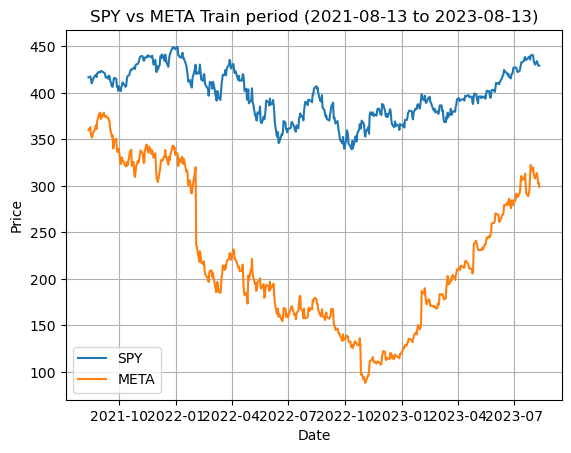

In [11]:
PAIR_Y, PAIR_X = "SPY", "META"
row = coint_df[(coint_df["y"] == PAIR_Y) & (coint_df["x"] == PAIR_X)]
assert len(row), f"{PAIR_Y}/{PAIR_X} not in the naive-cutoff list on this train window"
print(f"Selected pair: {PAIR_Y} / {PAIR_X}")
print(f"Train p-value: {row.iloc[0]['pval']:.5f}  (Bonferroni cutoff: {bonferroni_cutoff:.5f} — NOT met; naive 0.05 only)")

import matplotlib.pyplot as plt

Y_train = d_train[PAIR_Y]
X_train = d_train[PAIR_X]

plt.plot(Y_train, label=PAIR_Y)
plt.plot(X_train, label=PAIR_X)
plt.legend()
plt.title(f"{PAIR_Y} vs {PAIR_X} Train period ({TRAIN_START.date()} to {TRAIN_END.date()})")
plt.xlabel("Date"); plt.ylabel("Price"); plt.grid(True)
plt.show()

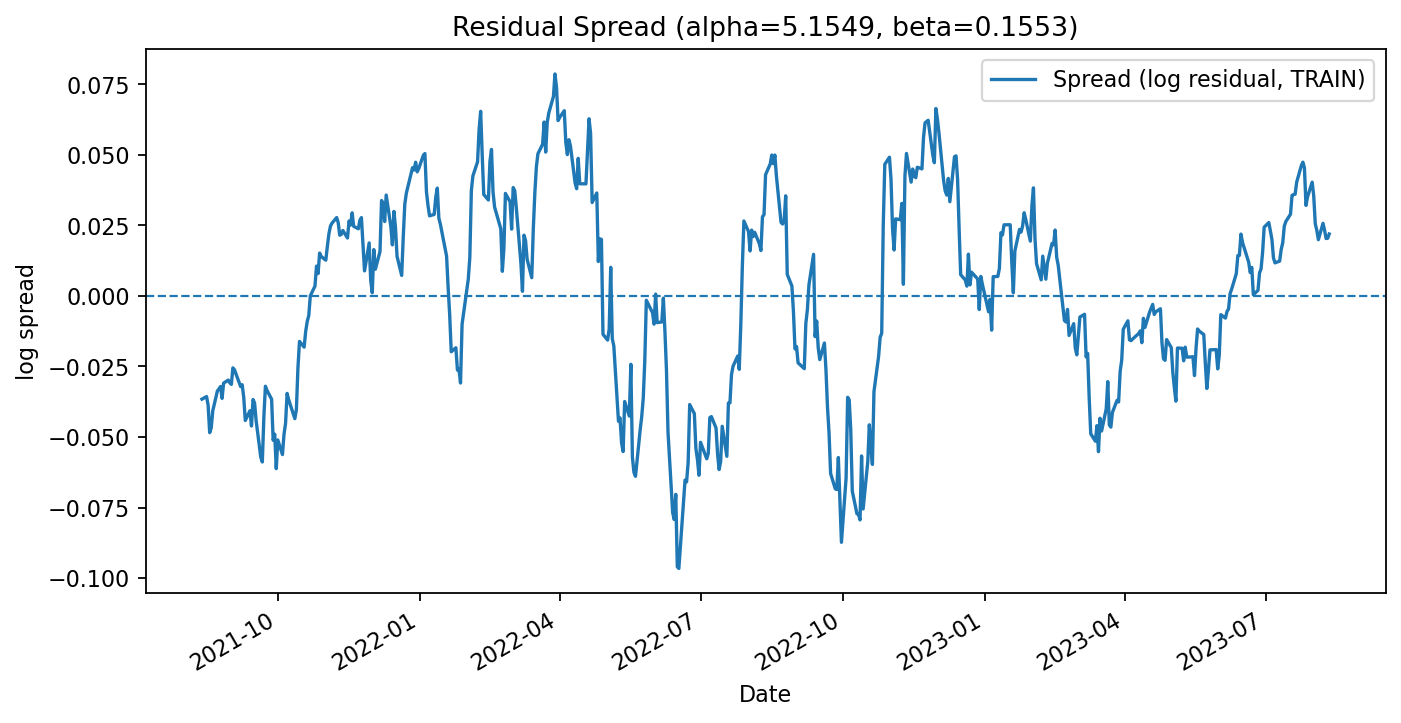

In [15]:
# Graphically representing the train-period spread to verify it looks stationary.

alpha_train, beta_train, resid_train = ols_beta(np.log(Y_train), np.log(X_train))

plt.figure(figsize=(10,5), dpi=160)
resid_train.plot(label="Spread (log residual, TRAIN)")
plt.axhline(0, ls="--", lw=1)
plt.title(f"Residual Spread (alpha={alpha_train:.4f}, beta={beta_train:.4f})")
plt.legend()
plt.xlabel("Date"); plt.ylabel("log spread")
plt.show()

## Half life of mean reversion: deriving the rolling window from the train data

The spread residual is modeled as an AR(1): $s_t = c + \varphi\, s_{t-1} + \varepsilon_t$. If $|\varphi| < 1$, a deviation from the mean decays by the factor $\varphi$ per day in expectation, so it halves after $h = -\ln 2 / \ln \varphi$ days. (The ADF test inside Engle-Granger tests $\varphi = 1$; this cell measures *how far below* 1 it is.) $\varphi$ is estimated via the equivalent regression $\Delta s_t = a + b\,s_{t-1} + \varepsilon_t$, with $\varphi = 1 + b$.

The rolling window's job is to estimate $\mu$, $\sigma$, and $\beta$ over several complete reversion cycles, so it is set to 3 half lives.

In [17]:
ds  = resid_train.diff().dropna()
lag = resid_train.shift(1).loc[ds.index]
b   = sm.OLS(ds, sm.add_constant(lag)).fit().params.iloc[1]
phi = 1.0 + b

if not (0.0 < phi < 1.0):
    print(f"phi = {phi:.4f} -> no measurable mean reversion in train residuals; "
          "falling back to a 26-day window.")
    HALF_LIFE = float("nan")
    ROLL_WIN = 26
else:
    HALF_LIFE = -np.log(2) / np.log(phi)
    ROLL_WIN = int(round(3*HALF_LIFE))
    print(f"phi (daily AR(1) coefficient): {phi:.4f}")
    print(f"Half-life of mean reversion:   {HALF_LIFE:.1f} trading days")
    print(f"Derived rolling window (3 x half-life): {ROLL_WIN} days")

phi (daily AR(1) coefficient): 0.9605
Half-life of mean reversion:   17.2 trading days
Derived rolling window (3 x half-life): 52 days


## Backtest: evaluated only on the TEST period

The rolling OLS below is computed across the full (train+test) series purely so the rolling window has enough trailing history to be populated right at the start of the test period.

In [19]:
logy_full = np.log(d_full[PAIR_Y])
logx_full = np.log(d_full[PAIR_X])

def rolling_ols_spread(logy, logx, window=126):
    idx = logy.index.intersection(logx.index)
    y, x = logy.loc[idx], logx.loc[idx]
    alpha = pd.Series(index=idx, dtype=float)
    beta  = pd.Series(index=idx, dtype=float)
    resid = pd.Series(index=idx, dtype=float)

    for i in range(window, len(idx)):
        ys = y.iloc[i-window:i]
        xs = x.iloc[i-window:i]
        X = sm.add_constant(xs)
        model = sm.OLS(ys, X).fit()
        a, b = model.params
        alpha.iloc[i], beta.iloc[i] = a, b
        resid.iloc[i] = y.iloc[i] - (a + b * x.iloc[i])

    mu = resid.rolling(window, min_periods=window//2).mean()
    sd = resid.rolling(window, min_periods=window//2).std(ddof=1)
    z  = (resid - mu) / sd
    out = pd.DataFrame({"alpha":alpha, "beta":beta, "resid":resid, "mu":mu, "sigma":sd, "z":z}).dropna()
    return out


model_full = rolling_ols_spread(logy_full, logx_full, window=ROLL_WIN)

model = model_full.loc[model_full.index >= TEST_START]
print(f"Rows available for signals in test window: {len(model)}")
model.tail(3)

Rows available for signals in test window: 501


,alpha,beta,resid,mu,sigma,z
Date,,,,,,
2025-08-08,3.397740,0.459063,-0.000900,0.005659,0.018008,-0.364252
2025-08-11,3.443400,0.452115,-0.000372,0.005462,0.018017,-0.323797
2025-08-12,3.420868,0.455537,-0.004091,0.005357,0.018058,-0.523254


In [21]:
ENTRY_Z = 2.0
EXIT_Z  = 0.5
STOP_Z  = 4.0

pos = pd.Series(0, index=model.index, dtype=int)
side = 0
for t in model.index:
    z = model.at[t, "z"]
    if side == 0:
        if z >= ENTRY_Z:
            side = -1   # short spread: short y, long beta*x
        elif z <= -ENTRY_Z:
            side = +1   # long spread: long y, short beta*x
    else:
        if abs(z) <= EXIT_Z or abs(z) >= STOP_Z:
            side = 0    # take profit or stop out
    pos.at[t] = side

print(pos.value_counts().rename("days").to_string())

 0    341
 1     86
-1     74


In [23]:
ry = logy_full.diff().reindex(model.index)
rx = logx_full.diff().reindex(model.index)
beta = model["beta"].ffill()

# Spread return
spread_ret = ry - beta * rx

# Position one day late to avoid look-ahead (execute next bar)
pnl_gross = pos.shift(1).fillna(0) * spread_ret

# Simple slippage model: 1 bps per side on position change
SLIPPAGE_BPS = 1.0
trades = pos.diff().abs().fillna(0)
slippage = trades * (SLIPPAGE_BPS / 10000.0)

ret_net = (pnl_gross - slippage).fillna(0.0)
equity = (1.0 + ret_net).cumprod()

bt = pd.DataFrame({
    "pos": pos,
    "z": model["z"],
    "beta": beta,
    "spread_ret": spread_ret,
    "gross_ret": pnl_gross,
    "slippage": slippage,
    "net_ret": ret_net,
    "equity": equity
}).dropna()
bt.tail(3)

,pos,z,beta,spread_ret,gross_ret,slippage,net_ret,equity
Date,,,,,,,,
2025-08-08,0,-0.364252,0.459063,0.003288,-0.003288,0.0001,-0.003388,1.145854
2025-08-11,0,-0.323797,0.452115,0.000041,0.000000,0.0000,0.000000,1.145854
2025-08-12,0,-0.523254,0.455537,-0.003541,-0.000000,0.0000,-0.000000,1.145854


Test period (2023-08-13 to 2025-08-13)
Sharpe: 0.825
Max DD: -7.3%
Trades: 12


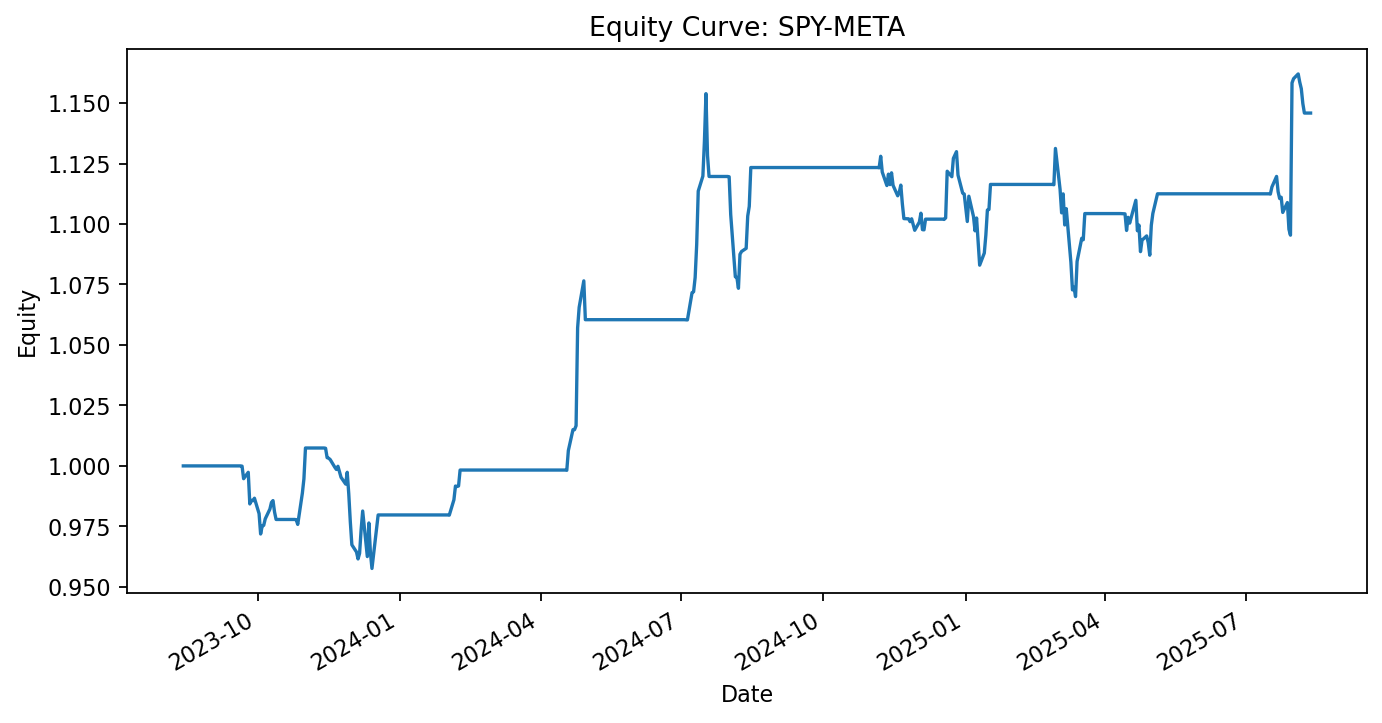

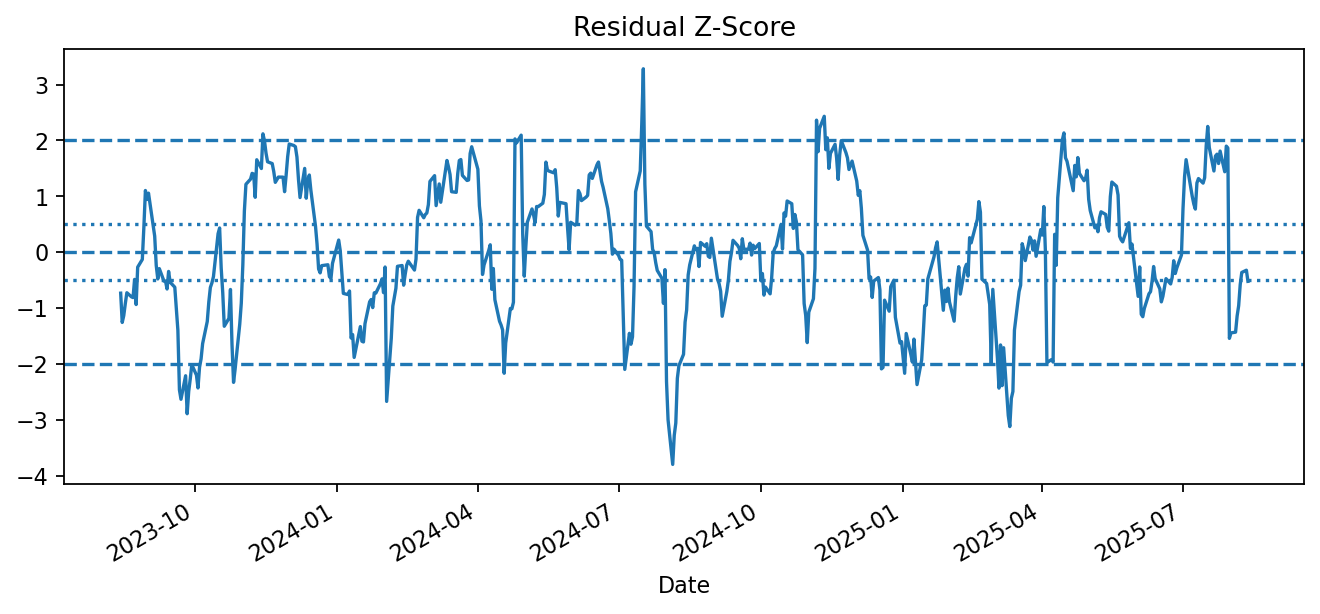

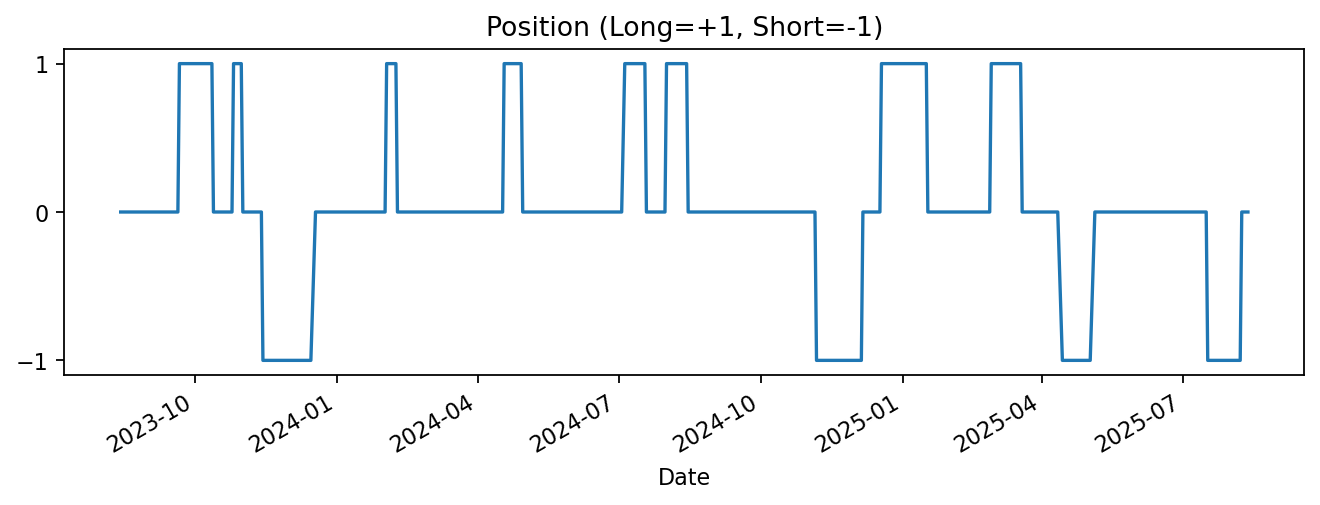

In [25]:
def sharpe(r, periods=252):
    r = r.dropna()
    if len(r) < 2 or r.std(ddof=1) == 0: return np.nan
    return float(r.mean()*periods / (r.std(ddof=1)*np.sqrt(periods)))

def max_drawdown(eq):
    peak = eq.cummax()
    dd = eq/peak - 1.0
    return float(dd.min())

print(f"Test period ({TEST_START.date()} to {TEST_END.date()})")
print("Sharpe:", round(sharpe(bt["net_ret"]), 3))
print("Max DD:", f'{100*max_drawdown(bt["equity"]):.1f}%')
print("Trades:", int(bt["pos"].diff().abs().sum()/2))  # rough count (entry+exit)

plt.figure(figsize=(10,5), dpi=160); bt["equity"].plot(title=f"Equity Curve: {PAIR_Y}-{PAIR_X}")
plt.xlabel("Date"); plt.ylabel("Equity"); plt.show()

plt.figure(figsize=(10,4), dpi=160); bt["z"].plot(title="Residual Z-Score")
plt.axhline(0, ls="--"); plt.axhline(ENTRY_Z, ls="--"); plt.axhline(-ENTRY_Z, ls="--")
plt.axhline(EXIT_Z, ls=":"); plt.axhline(-EXIT_Z, ls=":"); plt.show()

plt.figure(figsize=(10,3), dpi=160); bt["pos"].plot(title="Position (Long=+1, Short=-1)")
plt.yticks([-1,0,1]); plt.show()

As a benchmark, I compare the strategy's equity curve to a buy-and-hold investment in the S&P 500 over the same test window.

In [ ]:
bench = d_test['SPY'].dropna()
bench_ret = bench.pct_change().dropna()
bench_eq = (1 + bench_ret).cumprod()

plt.figure(figsize=(10,6), dpi=160)
bt['equity'].plot(label="Pairs Trading Strategy")
bench_eq.reindex(bt.index).plot(label="SPY (Buy & Hold)")
plt.legend()
plt.title("Equity Curve Comparison")
plt.ylabel("Cumulative Return")
plt.show()